# 05 · Two-domain mode-shape map — D-NS and D-ESBS from PPLN domain pairs

Runs the notebook-03 active-learning loop with the sample hopping between **two marked
spots, one in each PPLN domain orientation, at every laser position**. The piezoresponse
flips sign with the domain while the electrostatic response does not:

```
    Z_up   = +P + E                 P = (Z_up − Z_down) / 2   → piezo channel   → D-NS
    Z_down = −P + E                 E = (Z_up + Z_down) / 2   → electrostatic   → D-ESBS
```

The decomposition is exact per (position, frequency) — no fit, no V_cpd needed.

**Why both domains at each laser position, rather than two full runs.** The laser
position along the cantilever is tracked *relatively* (DoLDMove), so a second pass
re-visiting "the same x" accumulates backlash and the difference/sum would mix slightly
different physical positions. Interleaving visits each x once: laser move + AutoWedge +
InvOLS happen once per position, then the *sample* hops between the two domains under
the tip — sample position and laser position are completely independent axes. This is
also the dense-sweep protocol (measure both orientations per position).

### Before you run — set up in Igor (once)
1. Take a PFM image that shows both domain orientations.
2. On that image, use the Force panel's **pick spot** to mark **Spot 1** in one domain
   and **Spot 2** in the other, comfortably inside each domain (the spot must stay in
   its domain within scanner drift/creep over the run). Spot numbering starts at 1 —
   index 0 is the scan origin.
3. **Leave that image window open.** `GoToSpot()` reads the marked spots off the open
   image and refuses (an Igor alert) without it.
4. Fixed tune window bracketing the resonance + antiresonance, no auto-recenter,
   resolution per `docs/SPAN_AND_SAMPLING.md`.
5. Park the detection laser where `START_AT` says.

Run the **spot shakedown** cell before the loop: it hops Spot 1 → Spot 2 → Spot 1 with
the tip withdrawn and prints the XY sensor at each, so a mis-marked spot costs seconds,
not a run.

## 1 · Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import win32com.client
from activemodemap.asylum import AFMLaserSweepAutomation, AsylumInstrument
from activemodemap import (make_conditions, run_series, separate_domains,
                           channel_spots, load_checkpoint)

igor = win32com.client.Dispatch('IgorPro.Application')
print('Connected to Igor Pro')

Connected to Igor Pro


## 2 · Parameters

In [2]:
file_loc      = r'D:\User Data\Liam\ActiveModeMap\Domains1'   # must exist
base_filename = 'AMapD'
os.makedirs(file_loc, exist_ok=True)

# --- geometry / reachable span (x = 0 is the clamped BASE) ---
PROBE_L_UM = 225.0
START_AT   = 'free_end'
REACH_UM   = 118.0
step_um    = 1.0
x_grid     = np.arange(PROBE_L_UM - REACH_UM, PROBE_L_UM + 1e-6, step_um)
HW_SIGN_TOWARD_FREE_END = +1

# --- the two domains, as spots marked on the open image (numbering starts at 1) ---
SPOT_UP   = 1
SPOT_DOWN = 2      # which is physically 'up' only sets the sign of P; no null moves

# --- conditions ------------------------------------------------------------
# One bias keeps it lean: 2 tunes per position. NOTE at 0 V the electrostatic
# channel is only -V_cpd * S_elec — if V_cpd is small the D-ESBS is poorly
# conditioned. If the D-ESBS comes out noisy, set BIAS_V = [2.0], or use TWO
# biases (e.g. [1.0, 2.0], 4 tunes/position): that also enables the cross-bias
# consistency check in section 6, which is the only guard against a contact-gain
# difference between the spots leaking piezo into the electrostatic channel.
BIAS_V  = [0.0]
LOAD_NN = [2000.0]
conditions = make_conditions(BIAS_V, LOAD_NN, spots=[SPOT_UP, SPOT_DOWN])
REF_INDEX  = 0                      # spot-1 condition drives position selection

# --- reconstruction ---------------------------------------------------------
DNS_BAND_HZ   = (330e3, 470e3)
RANK          = 4
MIN_POSITIONS = 6                   # = RANK + 2
MAX_POSITIONS = 14
DNS_CI_TOL_UM = 1.0
RECALIBRATE_EACH = True

CHECKPOINT = os.path.join(file_loc, 'domains_checkpoint.npz')
print(f'{len(conditions)} conditions/position:', [str(c) for c in conditions])
print('per position: laser move + AutoWedge + InvOLS once, then '
      f'{len(conditions)} x (engage + tune) with ~2 sample hops')

2 conditions/position: ['+0.000 V, 2000 nN, spot 1', '+0.000 V, 2000 nN, spot 2']
per position: laser move + AutoWedge + InvOLS once, then 2 x (engage + tune) with ~2 sample hops


## 3 · Instrument, direction check

In [3]:
automation = AFMLaserSweepAutomation(igor, file_loc, base_filename, log_filename=None)
automation.eigenmode_center_freq = float(np.mean(DNS_BAND_HZ))
automation.autowedge_pause = 15.0
automation.invols_bounds = (4e-8, 10e-7)
automation.resonance_band_Hz = DNS_BAND_HZ
automation.wait_for_tune_complete = True
automation.tune_timeout_s   = 180.0
automation.verbose_tune     = True
# sample-spot move settling (GoToSpot): poll XY sensors until stable
automation.spot_timeout_s   = 90.0
automation.spot_stable_tol_V = 2e-3

inst = AsylumInstrument(automation, load_nN=LOAD_NN[0], dc_bias_V=BIAS_V[0],
                        recalibrate_each=RECALIBRATE_EACH, analysis_band_Hz=None,
                        start_at=START_AT, span_um=PROBE_L_UM,
                        x_limits_um=(x_grid[0], x_grid[-1]),
                        hw_sign_toward_free_end=HW_SIGN_TOWARD_FREE_END)

# Walking inward from the free end every move should read "toward base".
inst.preview_moves(list(x_grid[::-20]))

start: x = 225.0 um (free end, 0.0 um from the free end)
  x = 0 is the clamped base; hw_sign_toward_free_end = +1
  x =   225.0 um   DoLDMove(    +0.0, 0)   no move
  x =   205.0 um   DoLDMove(   -20.0, 0)   toward base
  x =   185.0 um   DoLDMove(   -20.0, 0)   toward base
  x =   165.0 um   DoLDMove(   -20.0, 0)   toward base
  x =   145.0 um   DoLDMove(   -20.0, 0)   toward base
  x =   125.0 um   DoLDMove(   -20.0, 0)   toward base


## 3b · Spot shakedown — run this BEFORE the loop

Hops Spot 1 → Spot 2 → Spot 1 with the tip withdrawn and prints the XY sensors at
each. Check three things: the moves complete (no timeout warning), the two spots read
*different* XY (a no-motion note on the second hop means both spots are marked at the
same place), and — on the video/image — the tip really is over the intended domains.

In [4]:
automation.withdraw()
for s_ in (SPOT_UP, SPOT_DOWN, SPOT_UP):
    ok = inst.goto_spot(s_)
    xy = automation.read_xy_sensor()
    print(f'  spot {s_}: settled={ok}   XY sensor = ({xy[0]:+.4f}, {xy[1]:+.4f}) V')
print('now at spot', inst.current_spot)

      spot 1 reached after 3.1 s (XY = -0.8115, -1.6594 V)
  spot 1: settled=True   XY sensor = (-0.8115, -1.6594) V
      spot 2 reached after 3.0 s (XY = +0.4416, -1.6728 V)
  spot 2: settled=True   XY sensor = (+0.4416, -1.6729) V
      spot 1 reached after 3.1 s (XY = -0.8114, -1.6595 V)
  spot 1: settled=True   XY sensor = (-0.8114, -1.6595) V
now at spot 1


## 4 · Run the loop — both domains at every laser position

Interrupt any time; the checkpoint holds every completed position and re-running
resumes. A run interrupted mid-position loses only that position.

In [5]:
series = run_series(inst, x_grid, conditions,
                    ref_index=REF_INDEX, rank=RANK,
                    min_positions=MIN_POSITIONS, max_positions=MAX_POSITIONS,
                    dns_band_Hz=DNS_BAND_HZ, dns_ci_tol_um=DNS_CI_TOL_UM,
                    start_near_um=(x_grid[-1] if START_AT == 'free_end' else x_grid[0]),
                    checkpoint_path=CHECKPOINT, resume=True, verbose=True)
inst.close()
print(f"\n{series['x_um'].size} positions x {len(conditions)} conditions "
      f"x {series['freq_Hz'].size} frequencies")


=== position 1: x = 225.0 um (2 conditions) ===
      tune finished after 10.5 s
      cond 0: +0.00 V, 2000 nN -> 16000 pts, f_res 387.43 kHz
      spot 2 reached after 3.1 s (XY = +0.4416, -1.6729 V)
      tune finished after 10.4 s
      cond 1: +0.00 V, 2000 nN -> 16000 pts, f_res 387.79 kHz

=== position 2: x = 166.0 um (2 conditions) ===
      spot 1 reached after 3.1 s (XY = -0.8114, -1.6595 V)
      tune finished after 10.7 s
      cond 0: +0.00 V, 2000 nN -> 16000 pts, f_res 387.41 kHz
      spot 2 reached after 3.1 s (XY = +0.4416, -1.6729 V)
      tune finished after 10.5 s
      cond 1: +0.00 V, 2000 nN -> 16000 pts, f_res 387.52 kHz

=== position 3: x = 107.0 um (2 conditions) ===
      spot 1 reached after 3.0 s (XY = -0.8115, -1.6595 V)
      tune finished after 10.4 s
      cond 0: +0.00 V, 2000 nN -> 16000 pts, f_res 387.37 kHz
      spot 2 reached after 3.1 s (XY = +0.4416, -1.6729 V)
      tune finished after 10.4 s
      cond 1: +0.00 V, 2000 nN -> 16000 pts, f_res

## 5 · Difference and sum — D-NS and D-ESBS

Different estimators on purpose: the D-NS is the antiresonance branch crossing of the
piezo channel; the D-ESBS is a **spatial null** of the electrostatic channel at the
resonance frequency (the branch crossing cannot tell the channels apart). The D-ESBS
here is the blind spot at resonance — the operating point for resonance-enhanced PFM —
not the quasistatic one.

  D-NS   (piezo, branch crossing)      : 218.51 um
  D-ESBS (electrostatic, spatial null) : 218.36 um  [at 387.4 kHz, not quasistatic]
  electrostatic fraction of the strong signal: 24.2% at this bias (informational; a contact-gain difference between the spots leaks piezo into this channel — verify with a second bias)

D-NS   = 6.49 µm from the free end
D-ESBS = 6.64 µm from the free end
saved Domains_result.npz / Domains_channels.png / Domains_log.csv


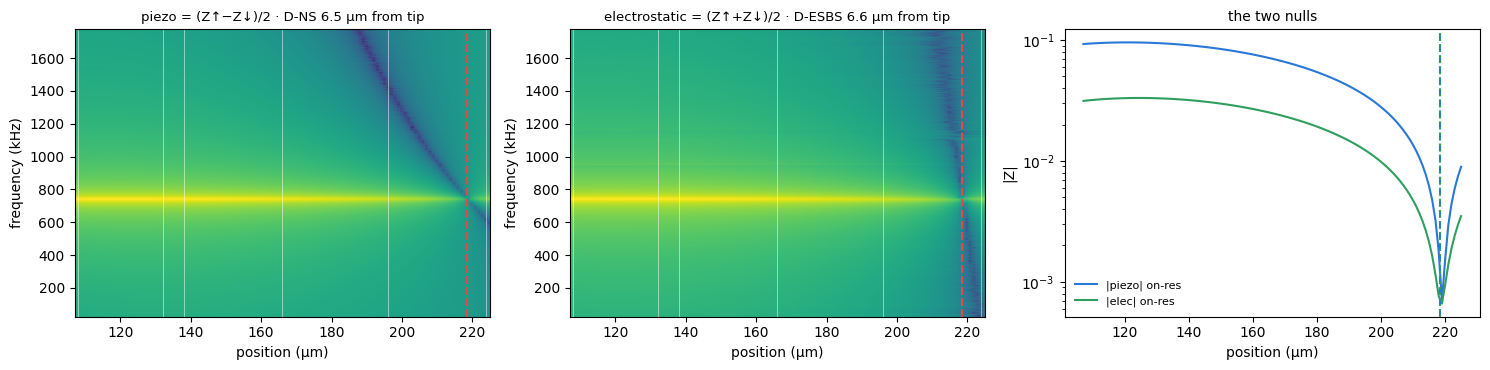

In [6]:
ch = separate_domains(series, spot_up=SPOT_UP, spot_down=SPOT_DOWN,
                      bias_V=BIAS_V[0], load_nN=LOAD_NN[0])
spots = channel_spots(ch, x_grid, rank=RANK, band_Hz=DNS_BAND_HZ)
dns_um, desbs_um = spots['dns']['value_um'], spots['desbs']['value_um']
print(f"\nD-NS   = {PROBE_L_UM - dns_um:.2f} µm from the free end")
print(f"D-ESBS = {PROBE_L_UM - desbs_um:.2f} µm from the free end")

f_k = ch['freq_Hz'] / 1e3
ext = [x_grid[0], x_grid[-1], f_k[0], f_k[-1]]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a, key, ttl in ((ax[0], 'dns', f'piezo = (Z↑−Z↓)/2 · D-NS {PROBE_L_UM-dns_um:.1f} µm from tip'),
                    (ax[1], 'desbs', f'electrostatic = (Z↑+Z↓)/2 · D-ESBS {PROBE_L_UM-desbs_um:.1f} µm from tip')):
    a.imshow(np.log10(np.abs(spots[key]['Zrec']).T + 1e-14), origin='lower',
             aspect='auto', extent=ext, cmap='viridis')
    for xv in series['x_um']:
        a.axvline(xv, color='w', lw=0.5, alpha=0.7)
    a.axvline(spots[key]['value_um'], color='#e34948', ls='--', lw=1.5)
    a.set_title(ttl, fontsize=9.5); a.set_xlabel('position (µm)'); a.set_ylabel('frequency (kHz)')
iresP = int(np.argmin(np.abs(spots['dns']['freq_Hz'] - spots['dns']['f_res_Hz'])))
iresE = int(np.argmin(np.abs(spots['desbs']['freq_Hz'] - spots['desbs']['f_res_Hz'])))
ax[2].semilogy(x_grid, np.abs(spots['dns']['Zrec'][:, iresP]), color='#2a78d6', label='|piezo| on-res')
ax[2].semilogy(x_grid, np.abs(spots['desbs']['Zrec'][:, iresE]), color='#2f9e5f', label='|elec| on-res')
ax[2].axvline(dns_um, color='#2a78d6', ls='--'); ax[2].axvline(desbs_um, color='#2f9e5f', ls=':')
ax[2].set_xlabel('position (µm)'); ax[2].set_ylabel('|Z|'); ax[2].legend(fontsize=8, frameon=False)
ax[2].set_title('the two nulls', fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(file_loc, 'Domains_channels.png'), dpi=150, bbox_inches='tight')

np.savez(os.path.join(file_loc, 'Domains_result.npz'),
         x_um=series['x_um'], freq_Hz=series['freq_Hz'], Z=series['Z'],
         x_grid=x_grid, piezo=ch['piezo'], elec=ch['elec'],
         bias_V=BIAS_V[0], load_nN=LOAD_NN[0],
         spot_up=SPOT_UP, spot_down=SPOT_DOWN,
         dns_um=dns_um, desbs_um=desbs_um, probe_L_um=PROBE_L_UM)
inst.save_log(os.path.join(file_loc, 'Domains_log.csv'))
print('saved Domains_result.npz / Domains_channels.png / Domains_log.csv')

## 6 · Cross-bias consistency (runs only if you measured ≥ 2 biases)

The one failure mode a single bias cannot catch: a contact-gain difference between the
two spots leaks piezoresponse into the electrostatic channel. E must scale with
(V − V_cpd); leaked P must not. So P from two biases should agree, and E should scale.

In [7]:
if len(BIAS_V) >= 2:
    chA = separate_domains(series, SPOT_UP, SPOT_DOWN, bias_V=BIAS_V[0], load_nN=LOAD_NN[0])
    chB = separate_domains(series, SPOT_UP, SPOT_DOWN, bias_V=BIAS_V[1], load_nN=LOAD_NN[0])
    tot = np.abs(chA['piezo']); strong = tot > 0.25 * tot.max()
    p_dev = np.median(np.abs(chA['piezo'][strong] - chB['piezo'][strong])
                      / (np.abs(chA['piezo'][strong]) + 1e-30))
    e_ratio = np.median(np.abs(chB['elec'][strong]) / (np.abs(chA['elec'][strong]) + 1e-30))
    print(f'P agreement across biases : {100*p_dev:.1f}% median deviation (want ~noise level)')
    print(f'E ratio {BIAS_V[1]:+.1f}V / {BIAS_V[0]:+.1f}V : {e_ratio:.2f} '
          '(should follow (V-V_cpd) scaling; also yields V_cpd = '
          f'{(e_ratio*BIAS_V[0]-BIAS_V[1])/(e_ratio-1):.2f} V if the ratio != 1)')
else:
    print('one bias measured — no cross-bias check available. If the D-ESBS matters, '
          're-run with BIAS_V = [1.0, 2.0].')

one bias measured — no cross-bias check available. If the D-ESBS matters, re-run with BIAS_V = [1.0, 2.0].


## Notes

- **Spot marking is the accuracy budget.** Scanner drift and creep move the sample
  under the tip over a ~20-minute run; mark spots well inside each domain, and glance
  at the PFM image afterwards to confirm both spots stayed in-domain.
- **Sign convention:** which spot is called 'up' only flips the sign of the piezo
  channel; neither null position depends on it.
- **The D-ESBS at 0 V bias** rides on −V_cpd·S_elec alone. Weak D-ESBS contrast →
  re-run with a deliberate bias, or two (section 6).
- **Automatic domain finding from a PFM image** (your option B) is deliberately not
  attempted here: acquiring, parsing and segmenting the image adds several failure
  modes for what one manual pick-spot avoids. If routine two-domain runs become common,
  that is the natural next automation step.
- Reprocess offline as usual — tune files carry `_S1`/`_S2` tags, so
  `scripts/reprocess_tune_folder.py --pattern "Tune_*_S1_*.txt"` selects one domain.